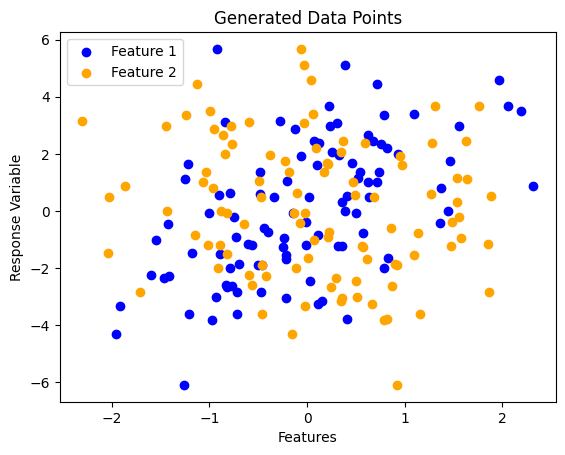

<function matplotlib.pyplot.show(close=None, block=None)>

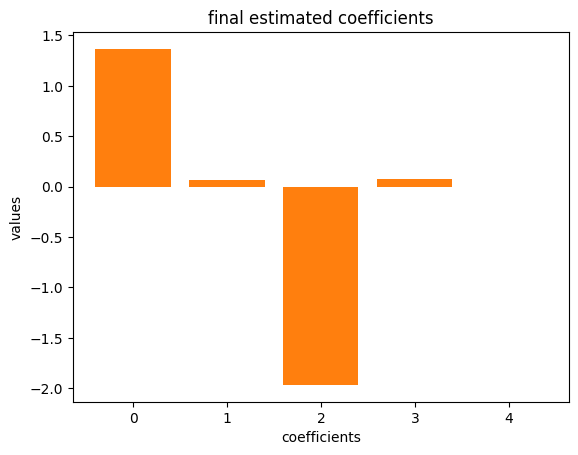

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def soft_thresholding(a,t):
    """Soft-thresholding operator."""
    if a > t:
        return a - t
    elif a < -t:
        return a + t
    else:
        return 0
    
def lasso_coor_descent(X, y, lambda_, num_iterations = 1000):
    """Lasso regression using coordinate descent"""
    n, p = X.shape
    beta = np.zeros(p)
    
    X = (X - np.mean(X, axis=0))/np.std(X, axis=0)
    
    for iteration in range(num_iterations):
        for j in range(p):
            r_j = y - X @ beta + X[:, j] * beta[j]
            
            gradient = np.dot(X[:, j], r_j)/n
            
            beta[j] = soft_thresholding(gradient, lambda_ / n)
            
    return beta

#generate synthetic data
np.random.seed(42)
X= np.random.randn(100,5) #100 samples,5 features
true_beta = np.array([1.5,0,-2,0,0]) #true coefficients
y=X@true_beta+np.random.randn(100)*0.5 #add some noice

#plotting the generated data
plt.scatter(X[:, 0], y, color = 'blue', label = 'Feature 1')
plt.scatter(X[:, 1], y, color = 'orange', label = 'Feature 2')
plt.xlabel('Features')
plt.ylabel('Response Variable')
plt.title('Generated Data Points')
plt.legend()
plt.show()

#initialize coefficients and plot initial values
beta_initial = np.zeros(X.shape[1])
plt.bar(range(len(beta_initial)), beta_initial)
plt.xlabel("coefficients")
plt.ylabel("values")
plt.title("initial coefficients")
plt.show

#set the regulariztion parameter
lambda_ = 0.1

#fit the lasso model
estimated_beta = lasso_coor_descent(X,y,lambda_)

#plot the estimated coefficients
plt.bar(range(len(estimated_beta)),estimated_beta)
plt.xlabel("coefficients")
plt.ylabel("values")
plt.title("final estimated coefficients")
plt.show

#print

            